In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:

import argparse
import time
import numpy as np
from sklearn.datasets import make_blobs

import hdbscan


from core_sg import CoreSGClusterer

# Building Dataset

In [3]:
n = 5000
d = 2
centers = 10
k = 30
seed = 42
atol = 1e-12
rtol = 1e-9

print(f"Generating synthetic dataset: n={n}, d={d}, centers={centers}, seed={seed}")
X, _ = make_blobs(
    n_samples=n,
    n_features=d,
    centers=centers,
    random_state=seed)

Generating synthetic dataset: n=5000, d=2, centers=10, seed=42


# Building CoreSG

In [4]:
%%time
# --- Build Core-SG (calculando pairwise dentro) ---
core_sg_clusterer = CoreSGClusterer(k_max=k, metric='euclidean',p=2,verbose=1,no_noise=False, match_reference_implementation=True)
core_sg_clusterer.fit(X, k=k)
core_sg_ = core_sg_clusterer.core_sg_

Core-SG build done in 4.29s
CPU times: user 4.62 s, sys: 370 ms, total: 4.99 s
Wall time: 4.29 s


**Labels for k_max**

In [5]:
core_sg_.labels_k_max_

array([1, 4, 2, ..., 3, 4, 0])

# Extracting MSTs for different k values

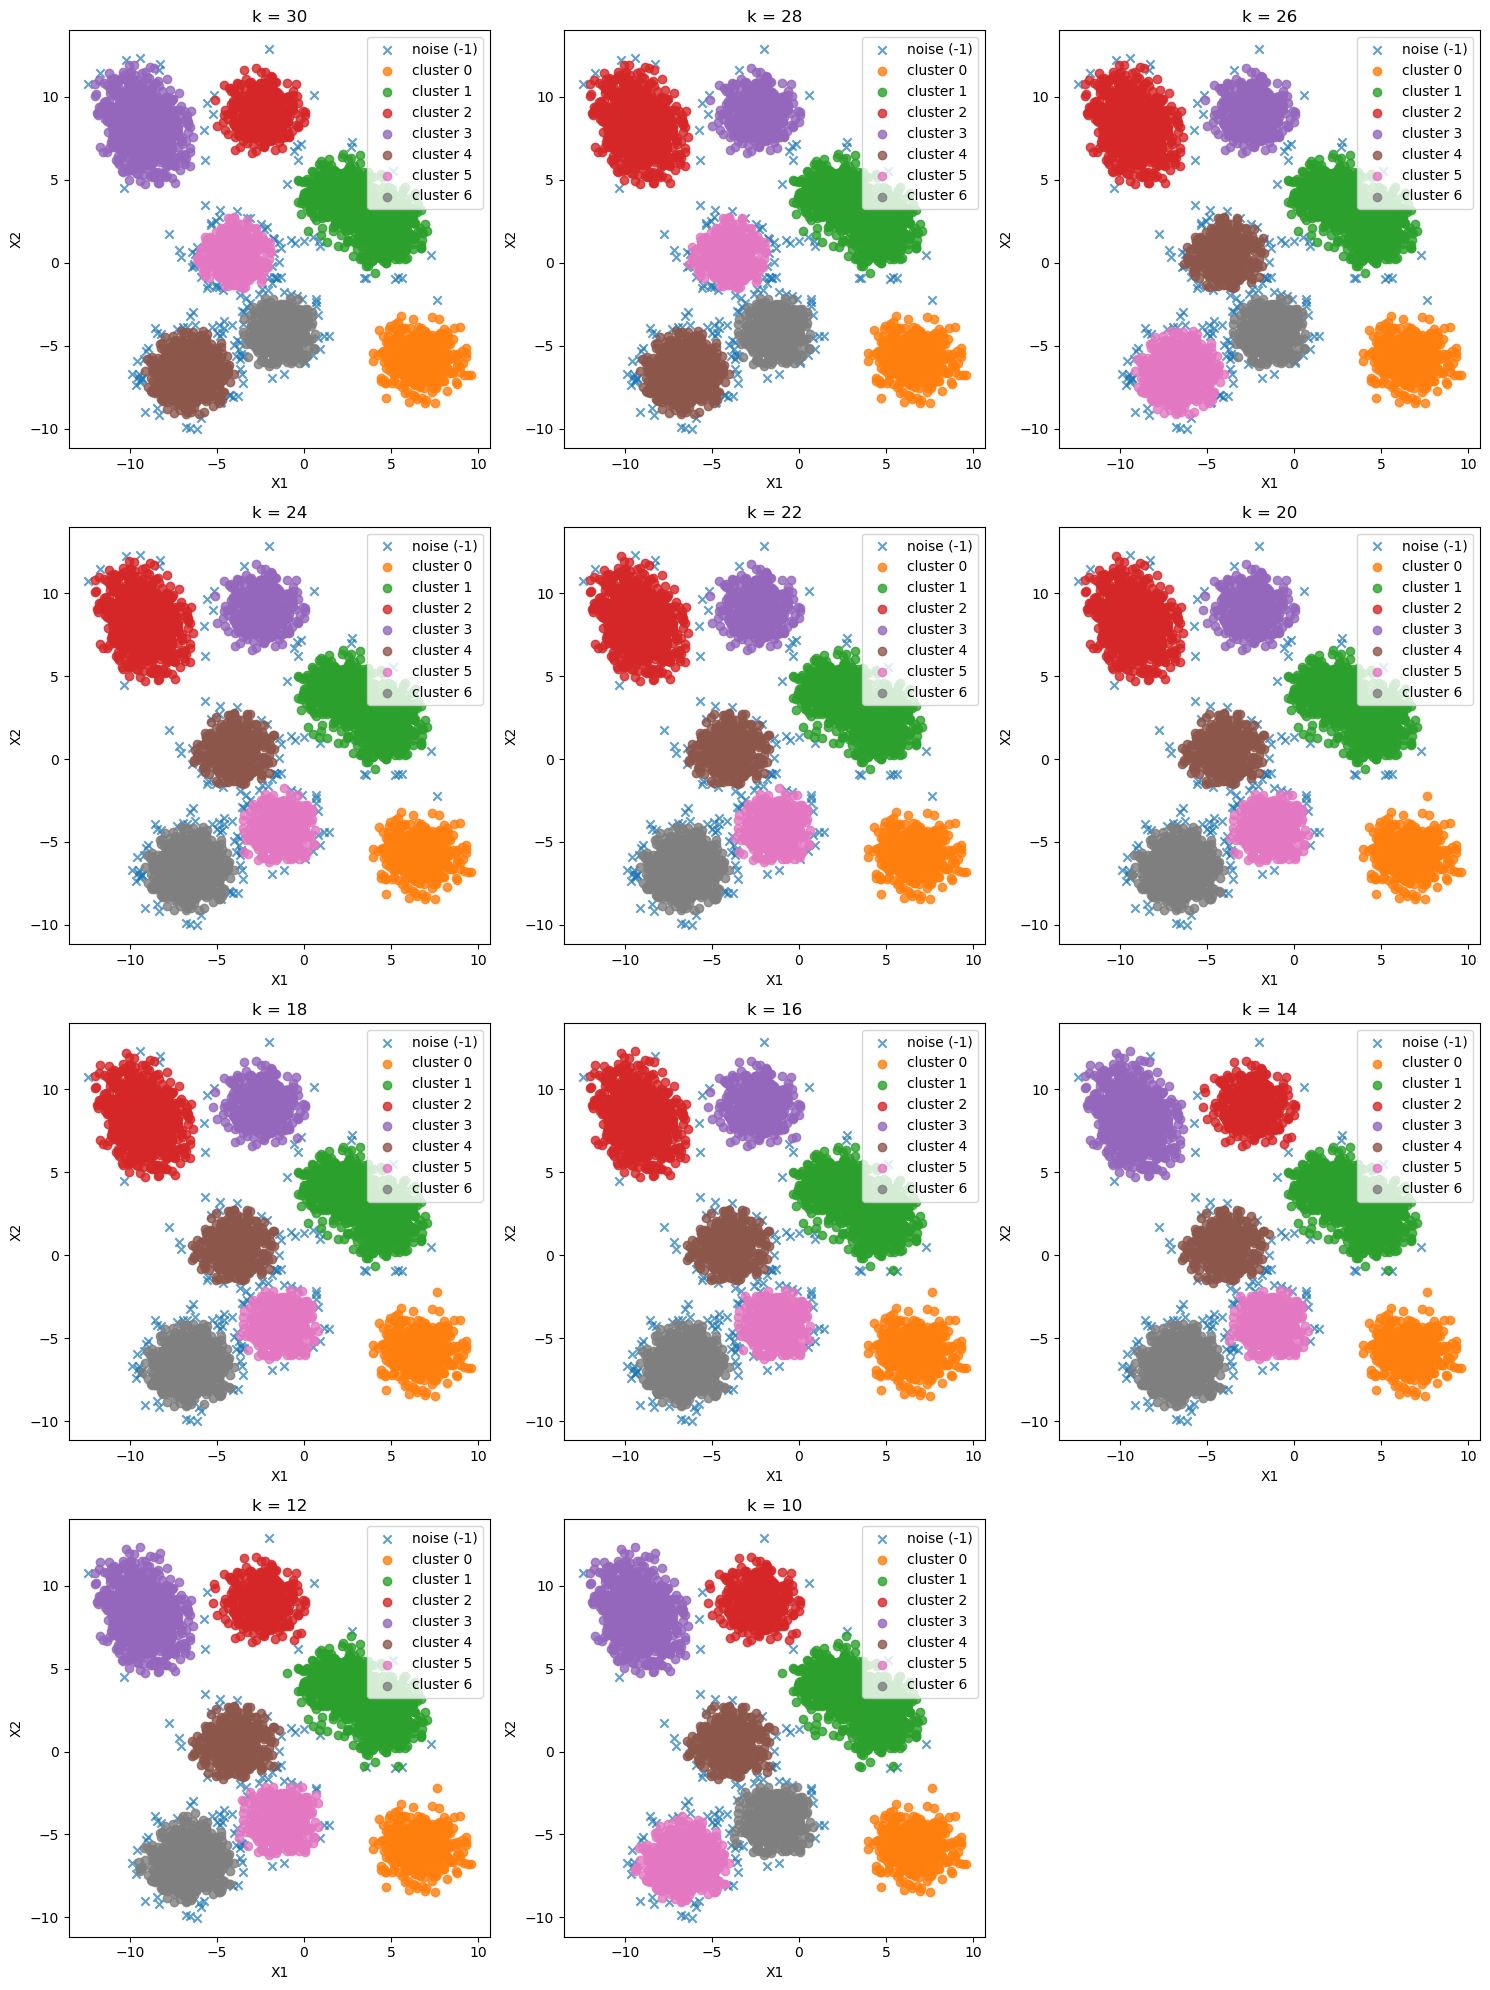

In [12]:
import math
import matplotlib.pyplot as plt
import numpy as np

results = []

core_sg_.set_verbose(False)
for k_iter in range(k, 8, -2):
    core_sg_.extract_hierarchy_from_core_sg(k_iter)
    labels = core_sg_.labels_.copy()
    results.append((k_iter, labels))
    #print(f"k={k_iter} -> labels: {labels}")

n_plots = len(results)
n_cols = min(3, n_plots)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (k_iter, labels) in zip(axes, results):
    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = labels == label

        if label == -1:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                label="noise (-1)",
                alpha=0.7,
                marker="x"
            )
        else:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                label=f"cluster {label}",
                alpha=0.8
            )

    ax.set_title(f"k = {k_iter}")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.legend()

for ax in axes[n_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Getting Core-SG  MRD K_pts

In [7]:
core_sg_.get_core_sg_mutual_reachability_distance(k=15)

array([[1.9590e+03, 4.5980e+03, 1.3030e-01],
       [1.9590e+03, 4.5980e+03, 1.3030e-01],
       [2.7960e+03, 3.8980e+03, 1.3110e-01],
       ...,
       [6.4500e+02, 2.9470e+03, 2.4672e+00],
       [2.9470e+03, 2.9890e+03, 2.4697e+00],
       [1.4530e+03, 2.9470e+03, 2.4945e+00]])

# Getting MST, Single Linkage e Condensed Tree

In [8]:
core_sg_.extract_hierarchy_from_core_sg(20)
attributes_val = {'mst': core_sg_.minimum_spanning_tree_,
                'slt': core_sg_.single_linkage_tree_,
                'condensed': core_sg_.condensed_tree_,
}

**MST**

In [9]:
attributes_val['mst'].to_pandas()

,from,to,distance
0,409,2163,0.1543
1,409,2904,0.1566
2,409,4715,0.1655
3,3497,4715,0.1665
4,409,4573,0.1677
...,...,...,...
4994,469,3856,1.9502
4995,420,2018,2.2433
4996,263,1972,2.2461
4997,2016,3848,2.2494


**Single Linkage Tree**

In [10]:
attributes_val['slt'].to_pandas()

,parent,left_child,right_child,distance,size
0,5000,409.0,2163.0,0.1543,2.0
1,5001,5000.0,2904.0,0.1566,3.0
2,5002,5001.0,4715.0,0.1655,4.0
3,5003,3497.0,5002.0,0.1665,5.0
4,5004,5003.0,4573.0,0.1677,6.0
...,...,...,...,...,...
4994,9994,9993.0,3856.0,1.9502,4498.0
4995,9995,9994.0,2018.0,2.2433,4499.0
4996,9996,9983.0,1972.0,2.2461,500.0
4997,9997,9996.0,9995.0,2.2494,4999.0


**Condesed Tree**

In [11]:
attributes_val['condensed'].to_pandas()

,parent,child,lambda_val,child_size
0,5000,2947,0.422511,1
1,5000,5001,0.444563,500
2,5000,5002,0.444563,4499
3,5001,1972,0.445216,1
4,5002,2018,0.445772,1
...,...,...,...,...
5041,5039,2796,5.580357,1
5042,5039,3317,5.580357,1
5043,5039,90,5.580357,1
5044,5039,1123,5.580357,1
